In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
modelo = joblib.load('../modelo_adaboost.pkl')

def simular_estrategia(modelo, colunas_X, total_voltas=30, composto_ativo='Compound_INTERMEDIATE'):
    dados_simulados = {
        'LapNumber' : list(range(1, total_voltas + 1)),
        'Stint' : [1.0] * total_voltas,
        'TyreLife' : list(range(1, total_voltas + 1))
    }

    for col in colunas_X:
        if col.startswith('Compound_'):
            dados_simulados[col] = [1 if col == composto_ativo else 0] * total_voltas

    df_simulacao = pd.DataFrame(dados_simulados)[colunas_X]
    df_simulacao['Tempo_Previsto'] = modelo.predict(df_simulacao)

    df_simulacao['Delta_Tempo'] = df_simulacao['Tempo_Previsto'].diff().fillna(0) 
    linha_cliff = df_simulacao.loc[df_simulacao['Delta_Tempo'].idxmax()]

    volta_cliff = int(linha_cliff['LapNumber'])
    perda_tempo = linha_cliff['Delta_Tempo']

    return df_simulacao, volta_cliff, perda_tempo # Reordena as colunas para corresponder ao conjunto de treinamento


In [3]:
colunas_X = ['LapNumber', 'Stint', 'TyreLife', 'Compound_INTERMEDIATE']
df_pista, volta_cliff, perda_tempo = simular_estrategia(modelo=modelo, colunas_X=colunas_X, total_voltas=30, composto_ativo='Compound_INTERMEDIATE')

#imprimir relatorio 

print("=" * 45)
print("      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      ")
print("=" * 45)
print(f"• Ponto de 'Cliff' detectado: Volta {volta_cliff}")
print(f"• Perda de ritmo estimada: +{perda_tempo:.3f}s")
print(f"• JANELA IDEAL DE PIT STOP: Voltas {volta_cliff - 1} a {volta_cliff}")
print("=" * 45)

      RELATÓRIO DE ESTRATÉGIA DE CORRIDA      
• Ponto de 'Cliff' detectado: Volta 15
• Perda de ritmo estimada: +0.518s
• JANELA IDEAL DE PIT STOP: Voltas 14 a 15


,LapNumber,Stint,TyreLife,Compound_INTERMEDIATE,Tempo_Previsto,Delta_Tempo
0,1,1.0,1,1,86.394000,0.000000
1,2,1.0,2,1,86.394000,0.000000
2,3,1.0,3,1,86.394000,0.000000
3,4,1.0,4,1,86.471000,0.077000
4,5,1.0,5,1,84.634857,-1.836143


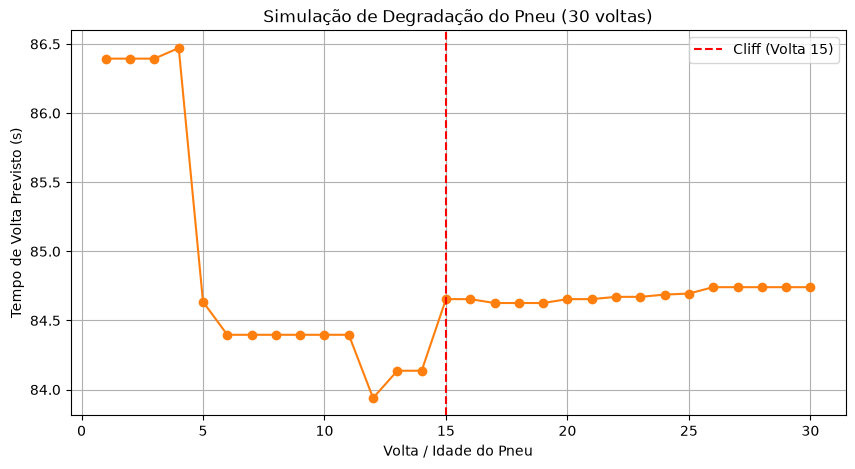

In [4]:

display(df_pista.head())

plt.figure(figsize=(10, 5))
plt.plot(df_pista['LapNumber'], df_pista['Tempo_Previsto'], marker='o', color='#ff7f0e')
plt.axvline(x=volta_cliff, color='red', linestyle='--', label=f'Cliff (Volta {volta_cliff})')
plt.title('Simulação de Degradação do Pneu (30 voltas)')
plt.xlabel('Volta / Idade do Pneu')
plt.ylabel('Tempo de Volta Previsto (s)')
plt.legend()
plt.grid(True)
plt.show()